# Noise Filtering (Simple Notebook)


## 1. Load sample frames (manual list)
These are a few representative frames for screenshots and comparisons.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

frame_paths = [
    "../data/frames/selected/alligator_cracking/alligator_cracking_01_frame_310.jpg",
    "../data/frames/selected/edge_cracking/edge_cracking_03_frame_325.jpg",
    "../data/frames/selected/potholes/potholes_01_frame_25.jpg",
    "../data/frames/selected/transverse_cracking/transverse_cracking_01_frame_570.jpg",
]


images = []
names = []

for path in frame_paths:
    img = cv2.imread(path, 0)
    if img is None:
        print("Error loading:", path)
    else:
        images.append(img)
        names.append(os.path.basename(path))

print("Loaded", len(images), "frames")

Loaded 4 frames


## 2. Define filters
- Mean filter (custom kernel)
- Gaussian blur (OpenCV)


In [2]:
def mean_filter(gray, k):
    kernel = np.ones((k, k), np.float32) / (k * k)
    return cv2.filter2D(gray, -1, kernel)

def gaussian_filter(gray, k):
    return cv2.GaussianBlur(gray, (k, k), 0)

## 3. Visual comparison (on-screen)
Shows original vs filtered images for k=3,5,7.

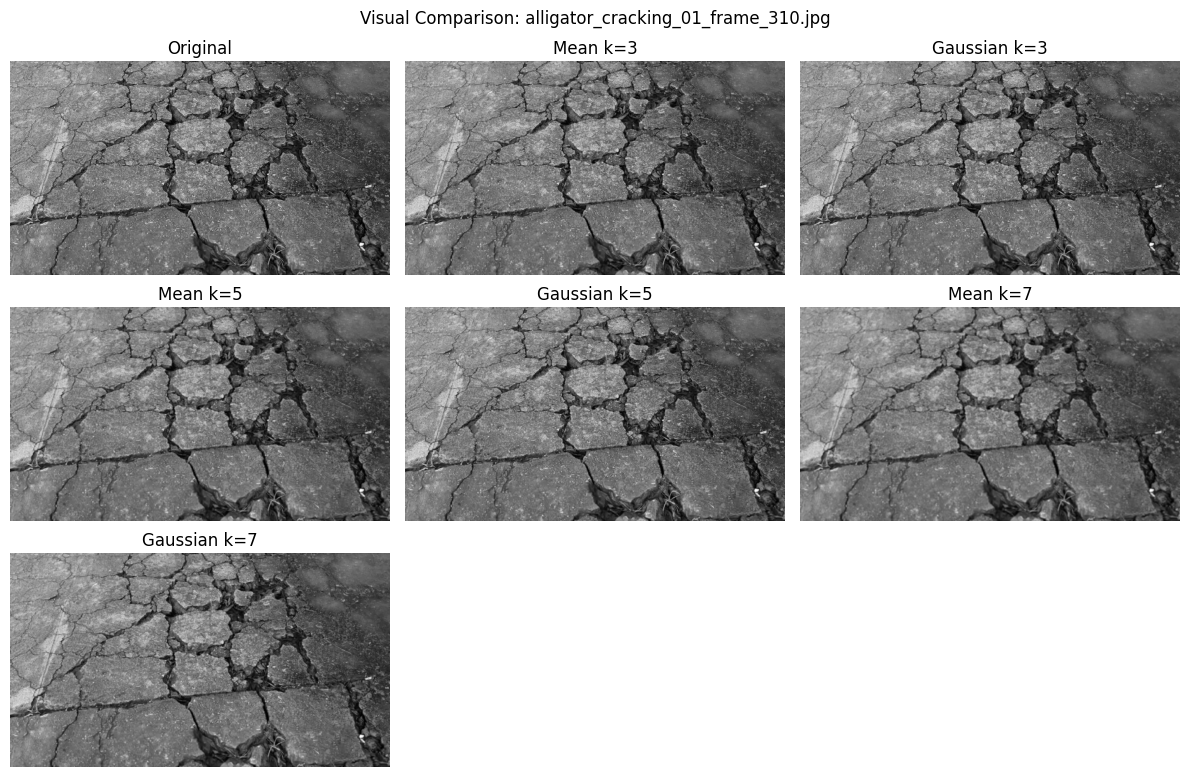

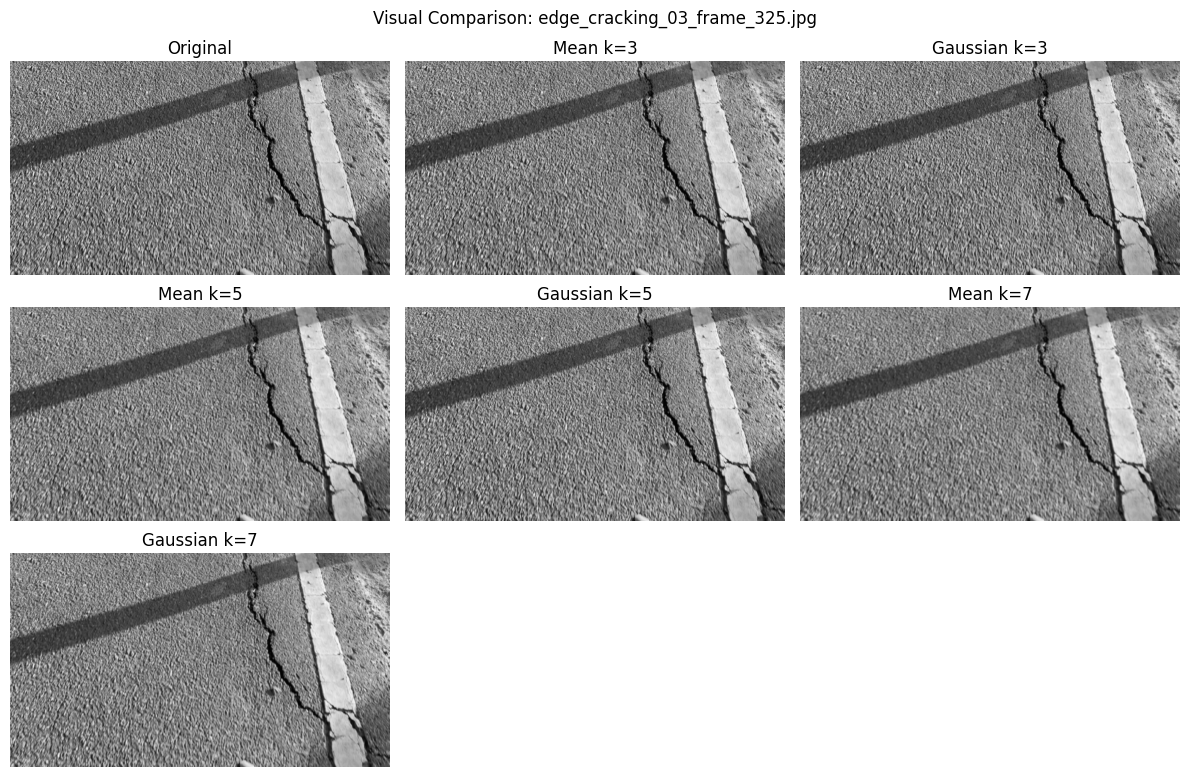

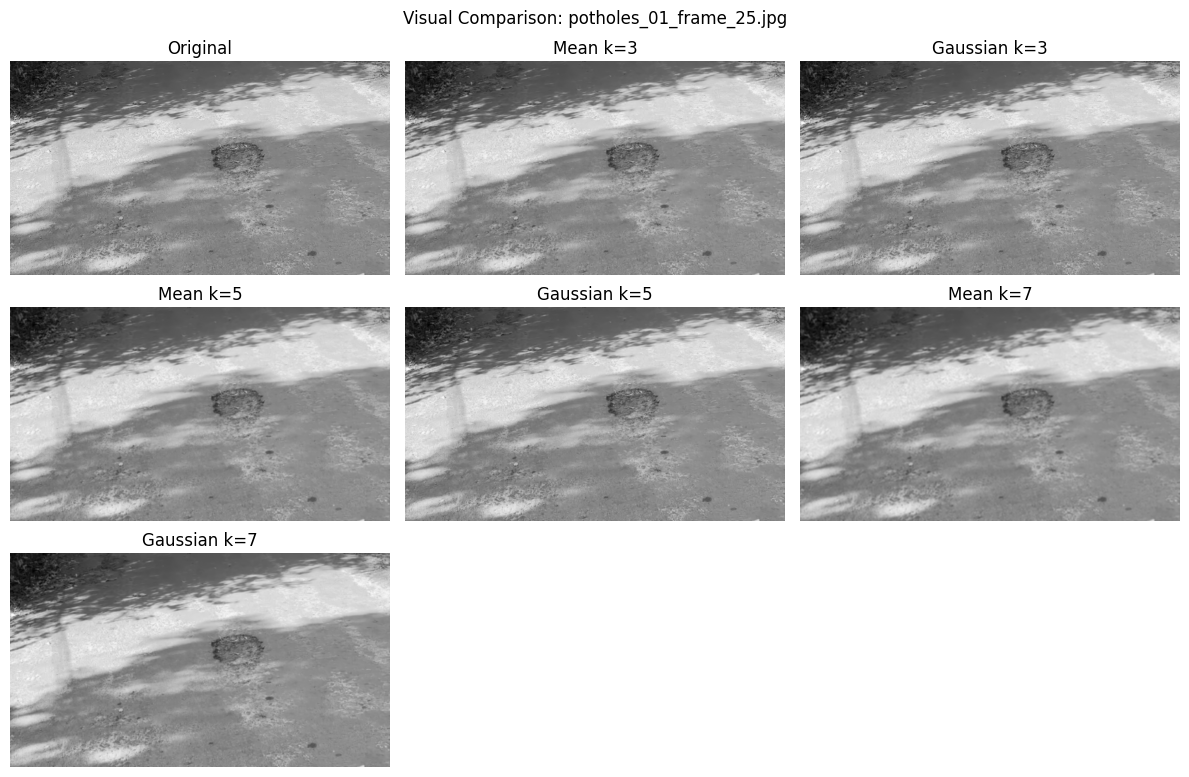

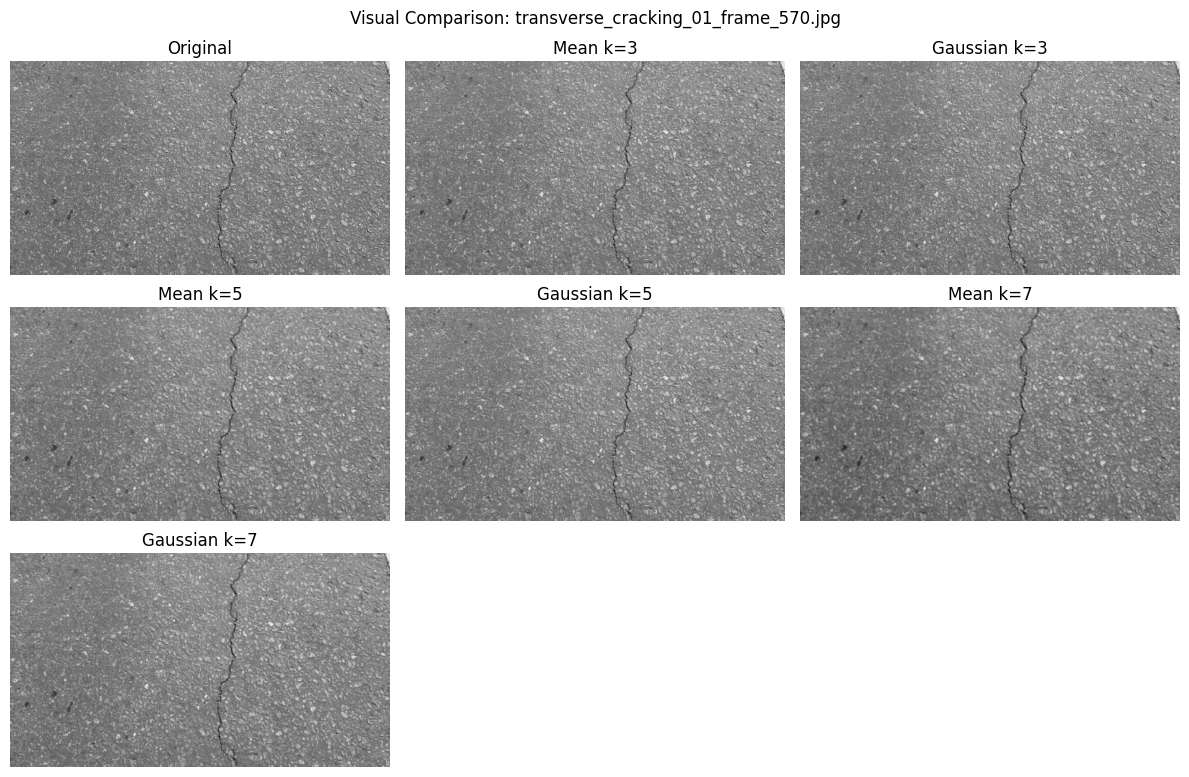

In [3]:
kernels = [3, 5, 7]

for img, nm in zip(images, names):
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, 3, 2)
    plt.imshow(mean_filter(img, 3), cmap="gray")
    plt.title("Mean k=3")
    plt.axis("off")

    plt.subplot(3, 3, 3)
    plt.imshow(gaussian_filter(img, 3), cmap="gray")
    plt.title("Gaussian k=3")
    plt.axis("off")

    plt.subplot(3, 3, 4)
    plt.imshow(mean_filter(img, 5), cmap="gray")
    plt.title("Mean k=5")
    plt.axis("off")

    plt.subplot(3, 3, 5)
    plt.imshow(gaussian_filter(img, 5), cmap="gray")
    plt.title("Gaussian k=5")
    plt.axis("off")

    plt.subplot(3, 3, 6)
    plt.imshow(mean_filter(img, 7), cmap="gray")
    plt.title("Mean k=7")
    plt.axis("off")

    plt.subplot(3, 3, 7)
    plt.imshow(gaussian_filter(img, 7), cmap="gray")
    plt.title("Gaussian k=7")
    plt.axis("off")

    plt.suptitle("Visual Comparison: " + nm)
    plt.tight_layout()
    plt.show()

## 4. Histogram comparison (on-screen)
Shows histograms for original vs filters.

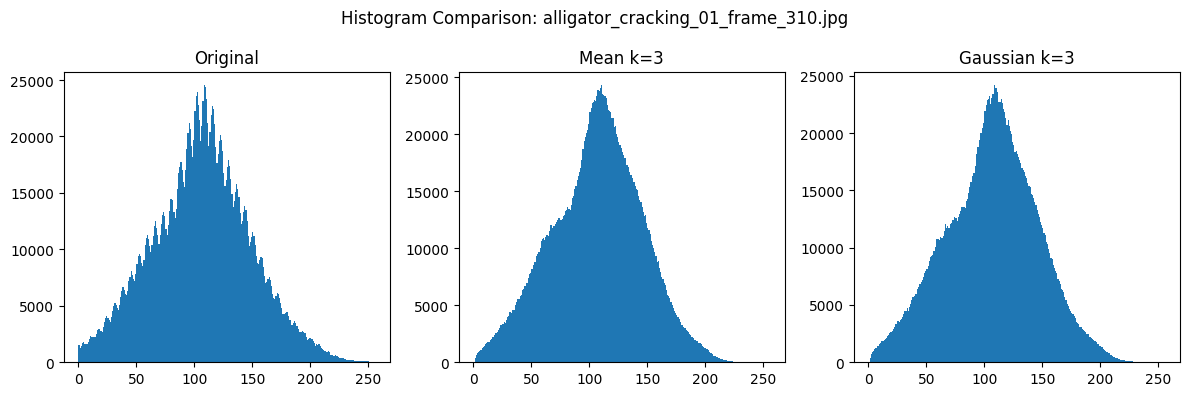

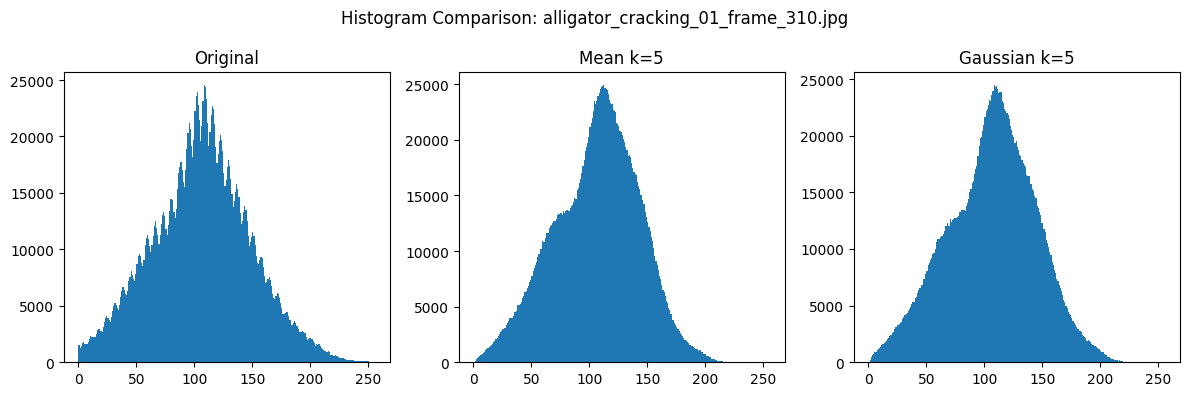

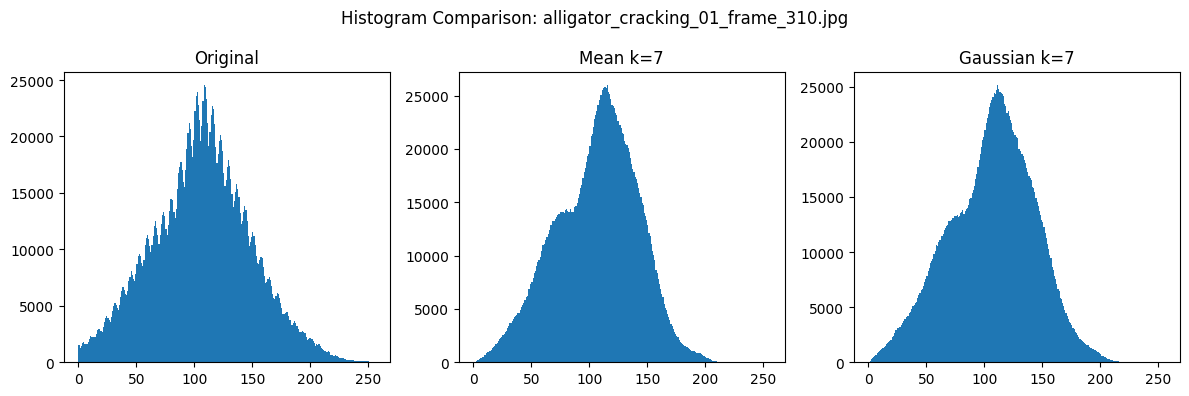

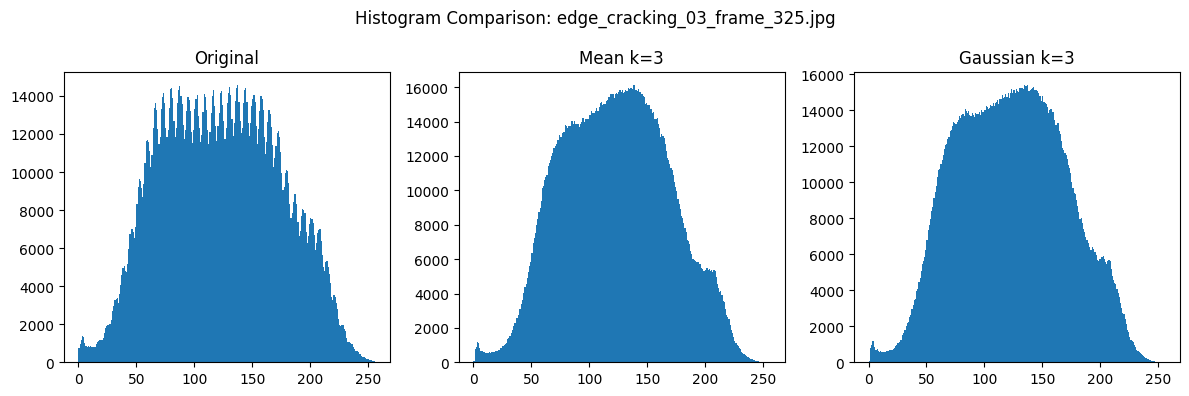

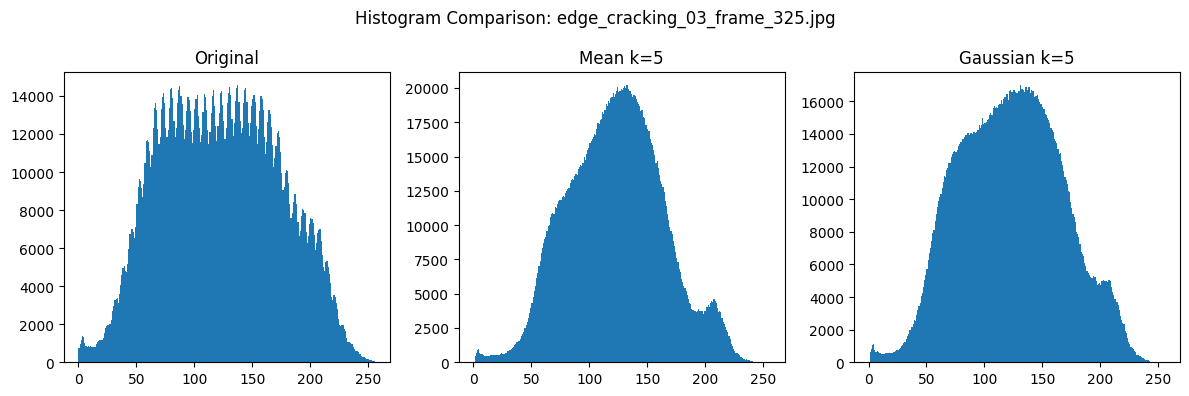

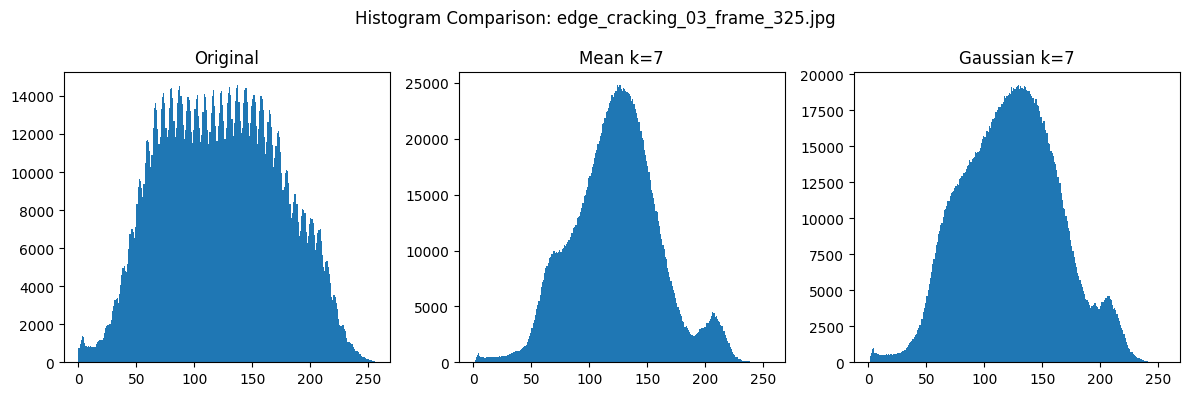

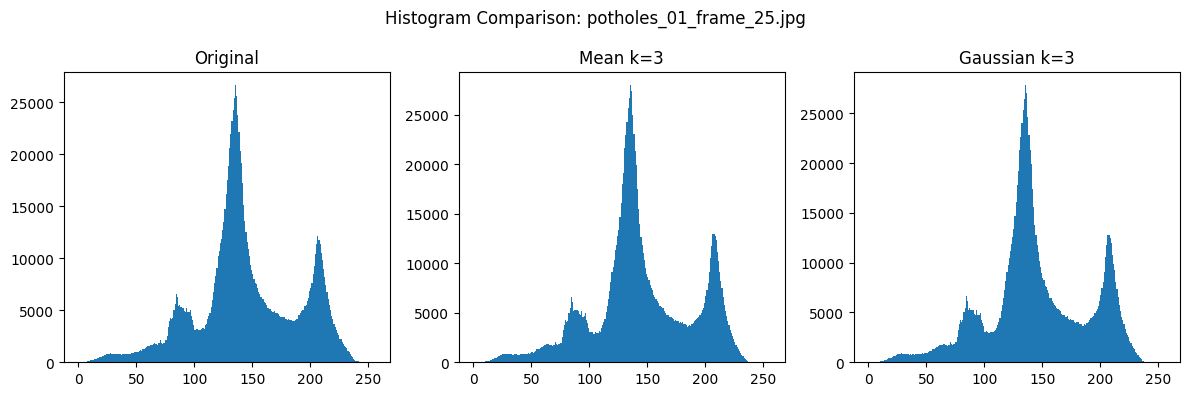

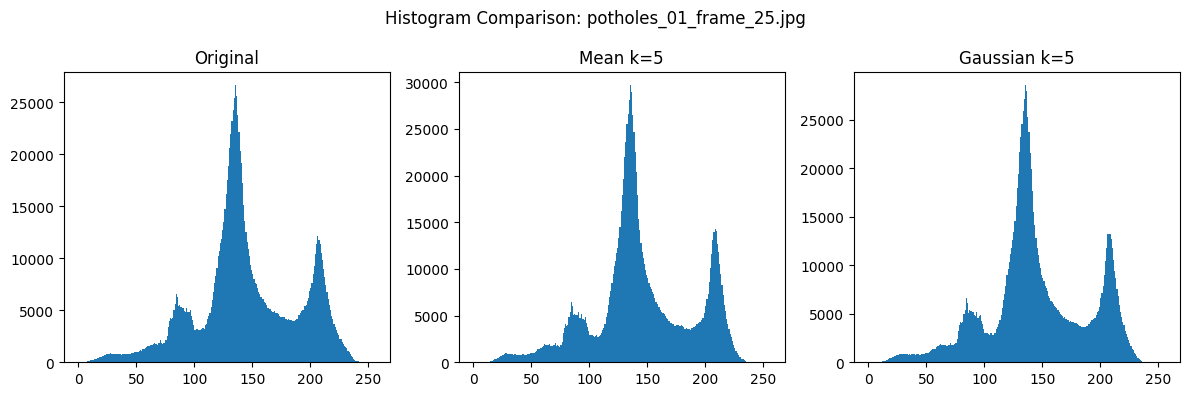

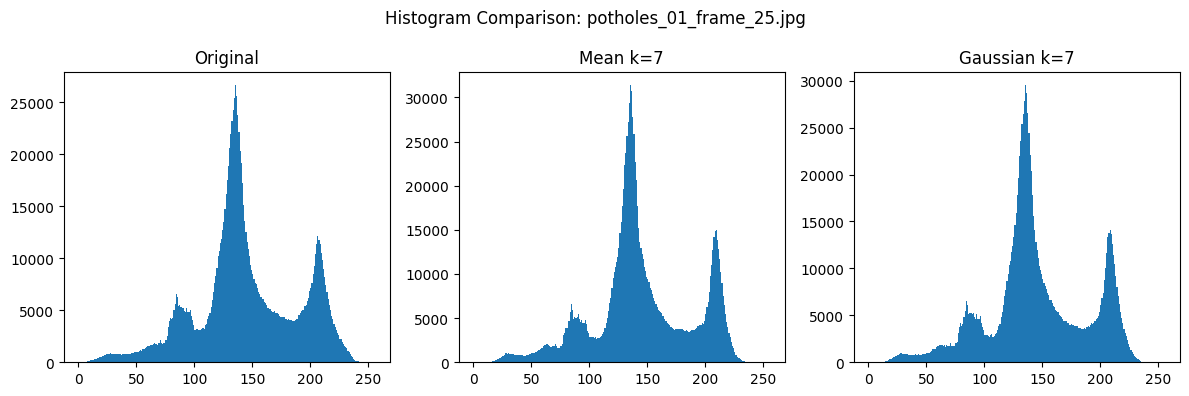

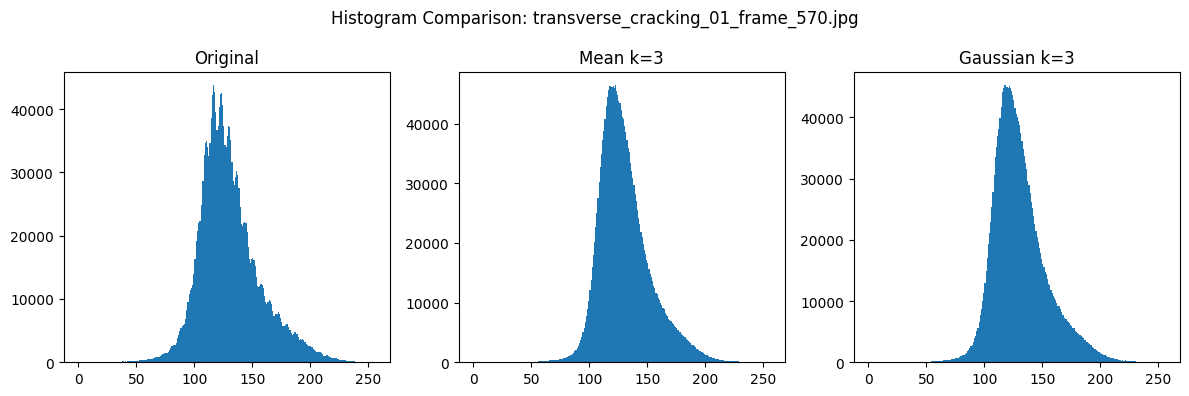

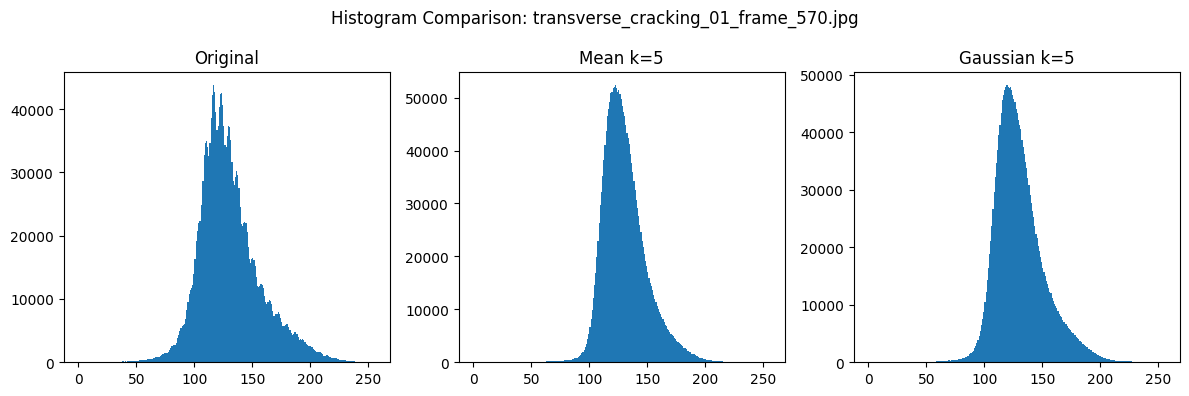

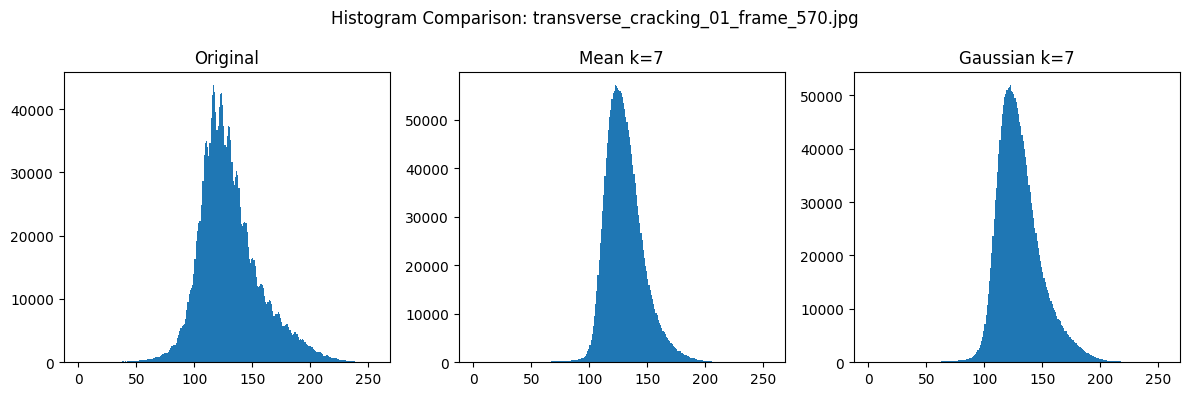

In [4]:
kernels = [3, 5, 7]

for img, nm in zip(images, names):
    for k in kernels:
        m = mean_filter(img, k)
        g = gaussian_filter(img, k)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.hist(img.ravel(), bins=256, range=(0, 256))
        plt.title("Original")

        plt.subplot(1, 3, 2)
        plt.hist(m.ravel(), bins=256, range=(0, 256))
        plt.title(f"Mean k={k}")

        plt.subplot(1, 3, 3)
        plt.hist(g.ravel(), bins=256, range=(0, 256))
        plt.title(f"Gaussian k={k}")

        plt.suptitle("Histogram Comparison: " + nm)
        plt.tight_layout()
        plt.show()

## 5. STD metric printout (on-screen)
Standard deviation is used as a simple indicator of intensity fluctuation reduction.


In [5]:
kernels = [3, 5, 7]

for img, nm in zip(images, names):
    print("\nFrame:", nm)
    print("Original STD:", np.std(img))

    for k in kernels:
        m = mean_filter(img, k)
        g = gaussian_filter(img, k)

        print(f"Mean k={k} STD:", np.std(m))
        print(f"Gaussian k={k} STD:", np.std(g))


Frame: alligator_cracking_01_frame_310.jpg
Original STD: 42.297123505722425
Mean k=3 STD: 38.99712744971866
Gaussian k=3 STD: 39.577244702155
Mean k=5 STD: 36.80159047882965
Gaussian k=5 STD: 38.31352630400646
Mean k=7 STD: 35.45699069003057
Gaussian k=7 STD: 37.046307637926624

Frame: edge_cracking_03_frame_325.jpg
Original STD: 50.57843709499367
Mean k=3 STD: 45.58462513990443
Gaussian k=3 STD: 46.606508603242794
Mean k=5 STD: 40.958764330539346
Gaussian k=5 STD: 44.25254428844661
Mean k=7 STD: 37.6021703249264
Gaussian k=7 STD: 41.531841832786895

Frame: potholes_01_frame_25.jpg
Original STD: 43.64928880293767
Mean k=3 STD: 43.129668143729425
Gaussian k=3 STD: 43.23284423463986
Mean k=5 STD: 42.694813716971176
Gaussian k=5 STD: 42.998926784143464
Mean k=7 STD: 42.3968910300389
Gaussian k=7 STD: 42.745745133059785

Frame: transverse_cracking_01_frame_570.jpg
Original STD: 26.65995193080136
Mean k=3 STD: 22.361675327141455
Gaussian k=3 STD: 23.185619561962135
Mean k=5 STD: 18.9117128

## 6. Save enhanced frames (selected → noise_removed)
This saves the chosen method output frames into the project folder structure.

In [6]:
categories = [
    "alligator_cracking",
    "edge_cracking",
    "potholes",
    "transverse_cracking"
]

def gaussian(img):
    return cv2.GaussianBlur(img,(3,3),0)


for category in categories:

    input_folder  = f"../data/frames/selected/{category}"

    output_folder = f"../data/frames/enhanced/noise_removed/{category}"

    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(input_folder):

        img_path = os.path.join(input_folder,file)

        img = cv2.imread(img_path,0)

        if img is None:
            continue

        out = gaussian(img)

        cv2.imwrite(os.path.join(output_folder,file), out)

    print("DONE:", category)

print("Noise removal completed.")

DONE: alligator_cracking
DONE: edge_cracking
DONE: potholes
DONE: transverse_cracking
Noise removal completed.


## 7. Report evidence export (added)

In [7]:
import csv

REPORT_DIR = "../results/report_evidence/noise"
os.makedirs(REPORT_DIR, exist_ok=True)

# choose ONE denoise method for report (simple)
def denoise(img):
    return gaussian_filter(img, 3)   # <-- change to mean_filter(img,3) if you want

def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

# ---------- (1) Save Before vs After images ----------
for img, nm in zip(images, names):
    out = denoise(img)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(out, cmap="gray"); plt.title("After Denoise"); plt.axis("off")
    plt.suptitle(nm)

    save_path = os.path.join(REPORT_DIR, nm.replace(".jpg","") + "_before_after.png")
    save_fig(save_path)

print("Saved before/after images:", REPORT_DIR)

# ---------- (2) Save Histogram comparison ----------
for img, nm in zip(images, names):
    out = denoise(img)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(img.ravel(), bins=256, range=(0,256))
    plt.title("Histogram - Original")

    plt.subplot(1,2,2)
    plt.hist(out.ravel(), bins=256, range=(0,256))
    plt.title("Histogram - After Denoise")

    plt.suptitle("Histogram Comparison: " + nm)

    save_path = os.path.join(REPORT_DIR, nm.replace(".jpg","") + "_hist_compare.png")
    save_fig(save_path)

print("Saved histogram comparisons:", REPORT_DIR)

# ---------- (3) Save simple metrics CSV (STD only) ----------
csv_path = os.path.join(REPORT_DIR, "noise_metrics_std.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["frame", "std_before", "std_after"])
    for img, nm in zip(images, names):
        out = denoise(img)
        w.writerow([nm, float(np.std(img)), float(np.std(out))])

print("Saved metrics CSV:", csv_path)

Saved before/after images: ../results/report_evidence/noise
Saved histogram comparisons: ../results/report_evidence/noise
Saved metrics CSV: ../results/report_evidence/noise\noise_metrics_std.csv
